**Generated notebook:** cell outputs have been cleared. Any summary quoted below comes from saved experiment artifacts, not a fresh execution of this source. Restore the original inputs and run the experiment driver before executing the notebook. See README.md for provenance and review limitations.

# Pipeline 1 — regime-aware shrinkage GMV

## TL;DR

The original five-restart, two-state HMM and probability-weighted covariance pooling are retained. This notebook corrects portfolio accounting and evaluates the same frozen specification on validation and test.

**Saved test result (2021-01-04–2026-02-20):** CAGR 7.55%; annual volatility 11.58%; daily CVaR95 1.66%; maximum drawdown 20.72%; annual two-sided turnover 5.95. Interpret these together with the incremental comparisons and uncertainty below.

In [1]:
from pathlib import Path
import os, sys, json, copy, warnings, tempfile
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "portfolio-mpl"))
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
# pandas 2.x / NumPy 2.4 emit this unrelated compatibility deprecation.
warnings.filterwarnings("ignore", message="The 'generic' unit for NumPy timedelta is deprecated.*", category=DeprecationWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from portfolio_research.workflow import *
from portfolio_research.features import prediction_diagnostics, forecast_risk, FEATURE_SETS
from portfolio_research.presentation import *
setup()
print({"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__, "project": str(ROOT)})

## Context & Methods

The primary baseline is **constrained Ledoit–Wolf global minimum variance (GMV)** within the Markowitz framework. It is not a Gaussian-mixture model (GMM). The regime extension uses a **two-state Gaussian hidden Markov model (HMM)**, relabelled calm/stress by its volatility state means. Calm/stress need not coincide with bull/bear returns.

The original frozen implementation settings are retained across the main comparison: **252 prior trading sessions, monthly rebalancing, long only, fully invested, 15% maximum target weight, and 10 basis points per dollar traded**. Keeping these settings fixed isolates the incremental information layers. They are inherited controls, not claimed to be optimal after correcting the old backtest.

- **Train, 2000–2016:** rolling covariance/HMM estimation; CatBoost training snapshots begin in 2010 because historical SEC XBRL coverage is sparse before then.
- **Validation, 2017–2020:** select only new quality/ML settings using the baseline risk score: volatility 30%, CVaR95 25%, drawdown 20%, turnover 10%, HHI 10%, Sharpe 5% (reverse-ranked).
- **Test, 2021–2026-02-20:** a common evaluation window after freezing all new settings. Rolling estimators and annual CatBoost refits may learn from earlier, fully observed test history, as a live strategy would; future labels and test-dependent parameter choices are forbidden.

### Key Assumptions

1. Signals end strictly before the return they earn. Fundamental facts have an additional one-business-day publication embargo and must already be available at the actual previous trading close. Close-only data imply idealized execution at the previous close; auction delays, overnight implementation and market impact are not simulated.
2. Holdings **drift every day** between scheduled rebalances. Two-sided L1 turnover is measured against drifted holdings. Costs reduce capital multiplicatively: `net = (1 - cost) * (1 + gross) - 1`. Initial investment costs are included; terminal liquidation is not imposed.
3. Sortino uses the baseline definition: annualized mean divided by annualized root-mean-square negative returns, with a zero required return. All return/risk tables use net daily simple returns and 252 sessions/year. VaR/CVaR are daily positive loss magnitudes, not annualized estimates. Maximum drawdown includes initial wealth of 1.
4. Security caps apply at rebalancing; holdings may drift above the cap between trades. Cash yield, taxes, borrowing and capacity constraints are outside this fully invested research protocol.
5. The universe contains **all 323 tickers** in the dated source snapshot with exactly one finite, positive adjusted close on each of its 6,573 dates. No alphabetical truncation is used. Historical delistings and time-varying index membership are still unavailable, so **survivorship and universe-selection bias remain**; the sample is a complete-history US large-cap panel, not a reconstructed constituent universe.
6. The 2021–2026 period is not used to select the frozen quality or CatBoost hyperparameters. Annual walk-forward refits may use only matured observations from earlier test dates, which is valid real-time updating. Because the original project had previously displayed this period, the study is best read as a transparent exploratory extension rather than a preregistered replication.

## Data

### Shared data and prior-only market snapshots

In [2]:
c = prepare_context()
display(c["summary"])
display(pd.DataFrame({"check": ["Price cells", "Missing prices", "Nonpositive prices", "Absolute daily returns > 20%"],
                      "value": [c["prices"].size, int(c["prices"].isna().sum().sum()), int(c["prices"].le(0).sum().sum()), int(c["returns"].abs().gt(.2).sum().sum())]}))
print("Common allocation settings:", asdict(CONFIG))

,start,end,days,assets,rows
split,,,,,
train,2000-01-03,2016-12-30,4277,323,1381471
validation,2017-01-03,2020-12-31,1007,323,325261
test,2021-01-04,2026-02-20,1289,323,416347


,check,value
0,Price cells,2123079
1,Missing prices,0
2,Nonpositive prices,0
3,Absolute daily returns > 20%,1246


### Inspect the market-state signals

The HMM uses an equal-weight market return, 20-day realized volatility, 63-day drawdown and 60-day mean pairwise correlation. Features are standardized inside each rolling HMM estimation window, never over the full sample.

,count,mean,std,min,25%,50%,75%,max
market_return,6513.0,0.000658,0.012439,-0.122051,-0.004720,0.000969,0.006381,0.110791
realized_volatility,6513.0,0.165855,0.109759,0.027794,0.103433,0.135711,0.190381,1.018590
drawdown,6513.0,-0.032944,0.048085,-0.435821,-0.043751,-0.015404,-0.002726,0.000000
average_correlation,6513.0,0.313219,0.126850,0.053120,0.220636,0.301345,0.378336,0.736583


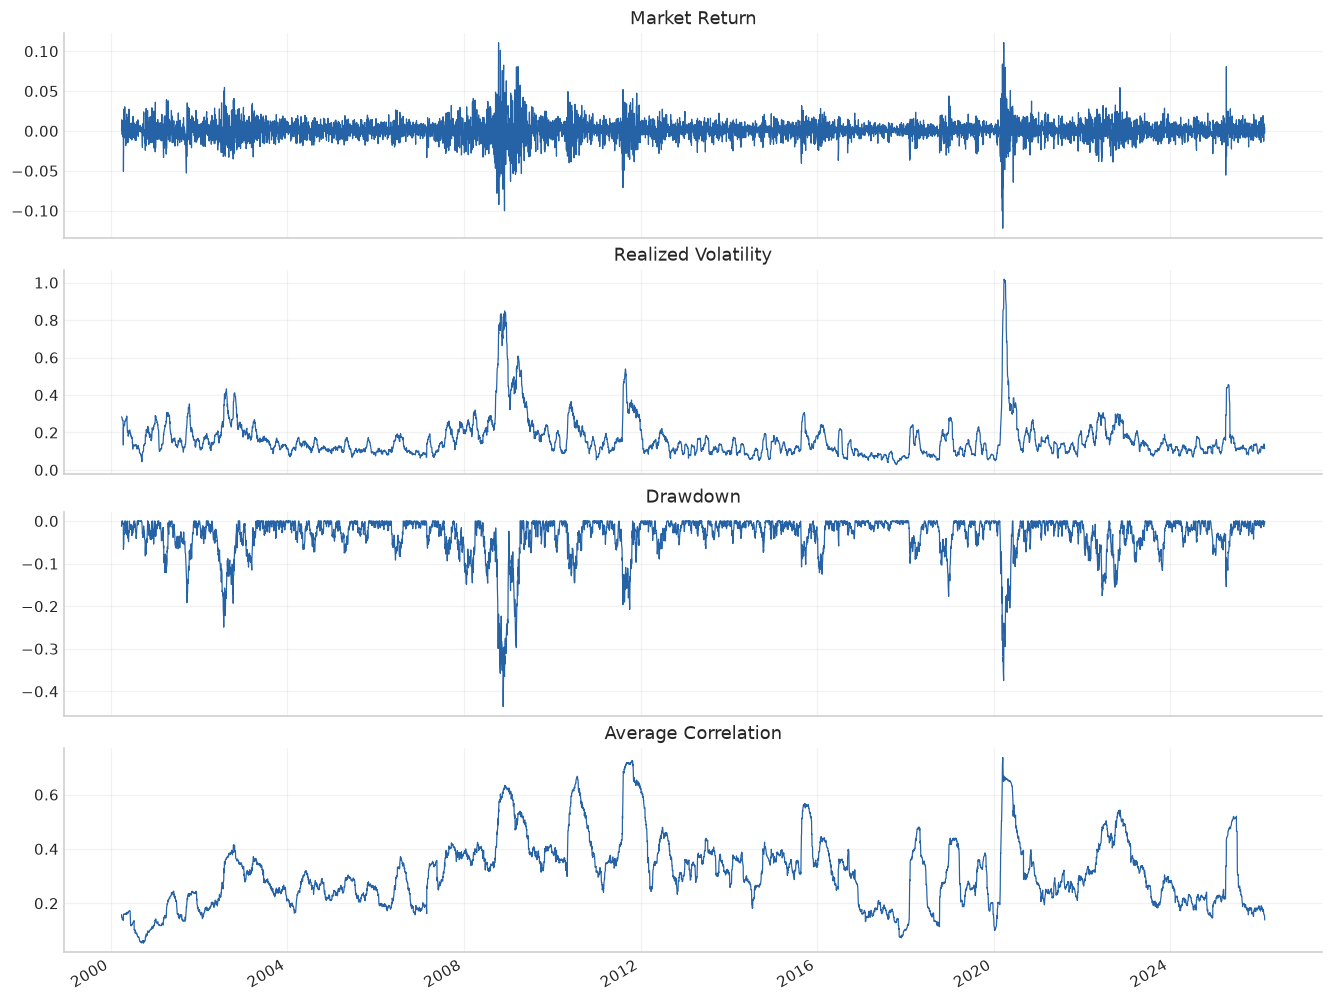

In [3]:
display(c["regime_features"].describe().T)
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True, layout="constrained")
for ax, feature in zip(axes, c["regime_features"].columns):
    c["regime_features"][feature].plot(ax=ax, color="#2563a6", lw=.8)
    ax.set(title=feature.replace("_", " ").title(), xlabel="")
save(fig, "pipeline1_market_features")

### Probability-weighted covariance construction

Each state covariance is pooled toward the ordinary shrinkage covariance with `alpha_k = n_eff / (n_eff + N)`. State probabilities are propagated for 21 trading days and averaged. The final covariance mixes these pooled matrices. Historical responsibilities can use observations already known at formation; the final state probability is filtered at that boundary. The state model is re-estimated at every monthly formation using up to 2,520 prior feature observations.

,forecast_stress_probability,calm_effective_observations,stress_effective_observations,regime_condition_number
2025-03-03,0.787945,174.587484,81.588092,731.080389
2025-04-01,0.790279,153.177424,103.126467,956.127115
2025-05-01,0.794162,144.32349,111.050079,1408.14528
2025-06-02,0.779942,129.994223,124.663142,1600.78842
2025-07-01,0.809429,110.073874,144.207766,1661.272167
2025-08-01,0.170505,106.145747,148.945273,1240.731177
2025-09-02,0.15362,114.213637,139.097755,1124.802101
2025-10-01,0.154443,114.103508,139.234826,1038.704884
2025-11-03,0.151168,114.294452,139.052694,1070.108344
2025-12-01,0.150631,112.151583,142.372295,1139.121328


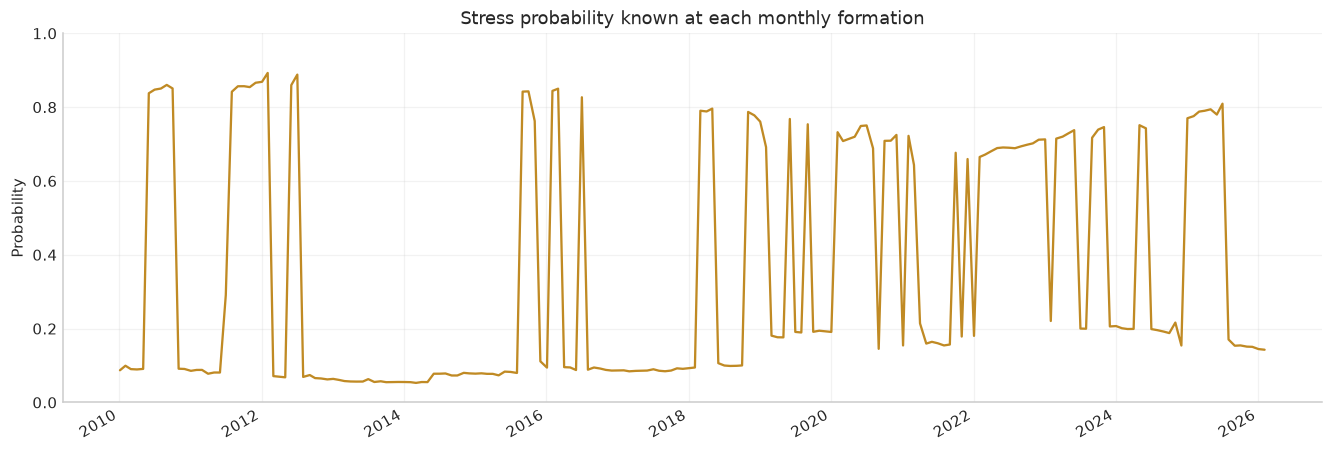

In [4]:
regime_diagnostics = pd.DataFrame({date: m["diagnostics"] for date, m in c["market"].items()}).T
regime_diagnostics.index = pd.DatetimeIndex(regime_diagnostics.index)
display(regime_diagnostics[["forecast_stress_probability", "calm_effective_observations", "stress_effective_observations", "regime_condition_number"]].tail(12))
fig, ax = plt.subplots(figsize=(12, 4), layout="constrained")
regime_diagnostics.forecast_stress_probability.astype(float).plot(ax=ax, color="#c08a24")
ax.set(title="Stress probability known at each monthly formation", ylabel="Probability", ylim=(0, 1))
save(fig, "pipeline1_formation_probabilities")

## Results

### Validation and test use the same HMM settings

In [5]:
validation_results = {name: strategy(c, "validation", name) for name in ["baseline", "pipeline1"]}
test_results = {name: strategy(c, "test", name) for name in ["baseline", "pipeline1"]}
for split, results in [("validation", validation_results), ("test", test_results)]:
    display(Markdown(f"**{split.title()}**")); display(styled(metric_table(results)[METRIC_COLUMNS]))
    for name, result in results.items(): verify_saved_result(result, name, split)
test_table = metric_table(test_results)

**Validation**

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
baseline,11.87%,15.75%,0.791,1.118,28.76%,2.37%,4.95%,5.457,21.446
pipeline1,11.85%,15.78%,0.789,1.117,28.63%,2.37%,4.95%,5.893,19.615


**Test**

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
baseline,7.45%,11.59%,0.678,0.955,20.61%,1.66%,2.65%,5.609,22.850
pipeline1,7.55%,11.58%,0.687,0.969,20.72%,1.66%,2.63%,5.946,21.859


### Reading the metrics

Lower volatility, CVaR and drawdown indicate less realized risk. Higher CAGR/Sharpe/Sortino indicate greater realized reward or reward per unit of risk. Turnover is the two-sided traded fraction per year, HHI is target-weight concentration, and effective breadth is `1 / HHI`. The sum of daily cost fractions is an implementation diagnostic, not the exact compounded drag on terminal wealth. Tables retain the baseline metric names and add implementation audits.

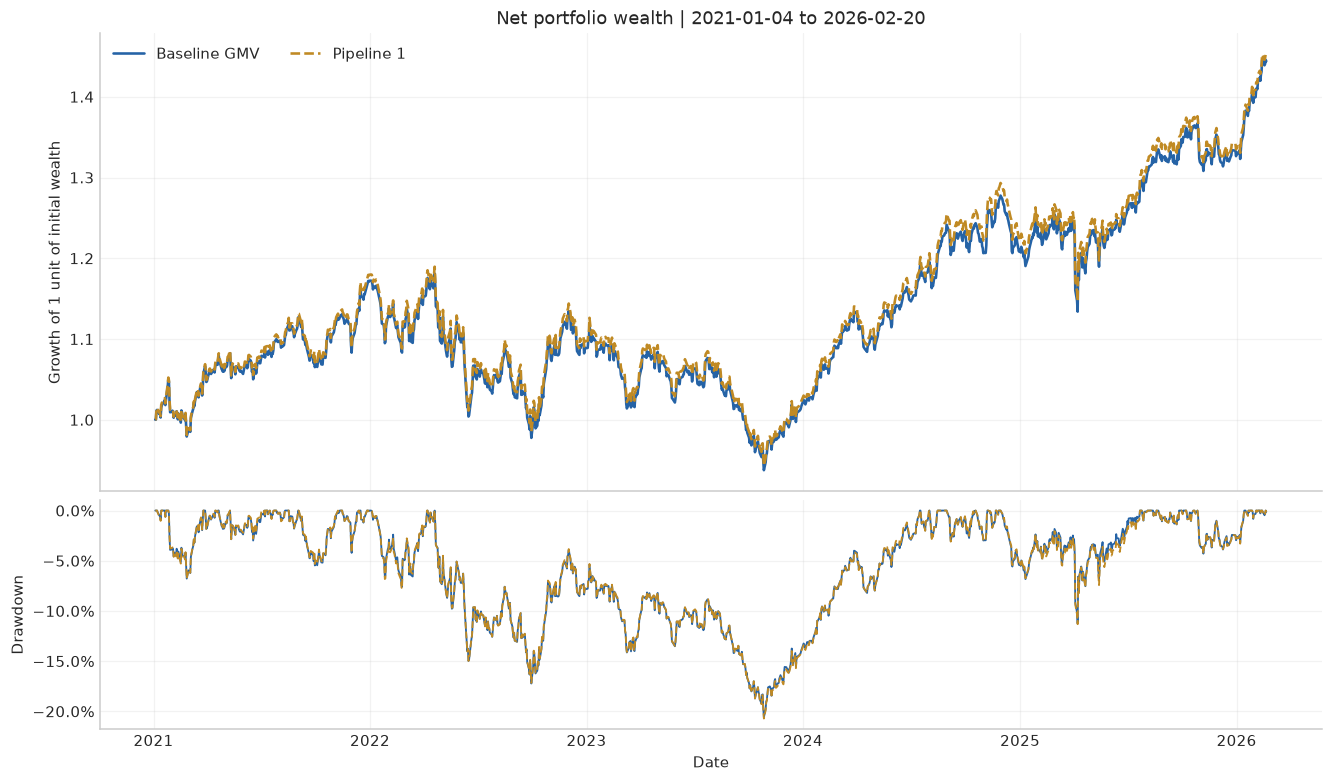

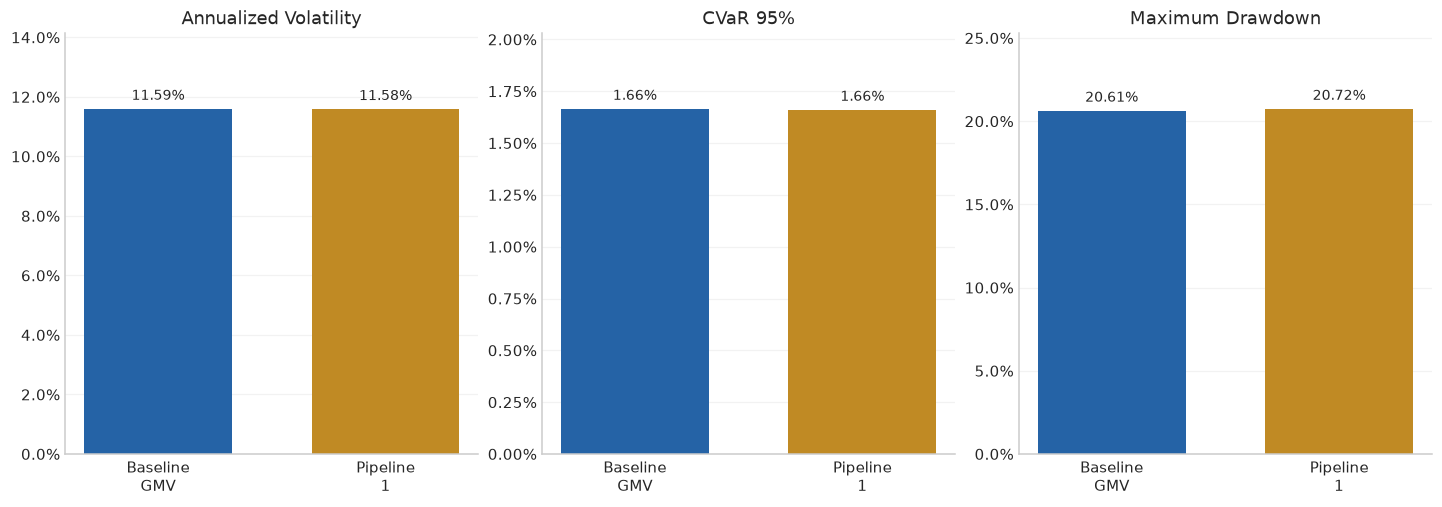

In [6]:
performance_plot(test_results, "pipeline1_test_performance")
risk_plot(test_table, "pipeline1_test_risk")

### Implementation cost and allocation structure

,Annualized Turnover,Total Transaction Costs,Average HHI,Average Effective Assets,Mean Target L1 Change,Solver Failures,HMM Fallbacks
baseline,5.609,2.87%,4.88%,22.850,0.451,0.000,0.000
pipeline1,5.946,3.04%,5.06%,21.859,0.480,0.000,0.000


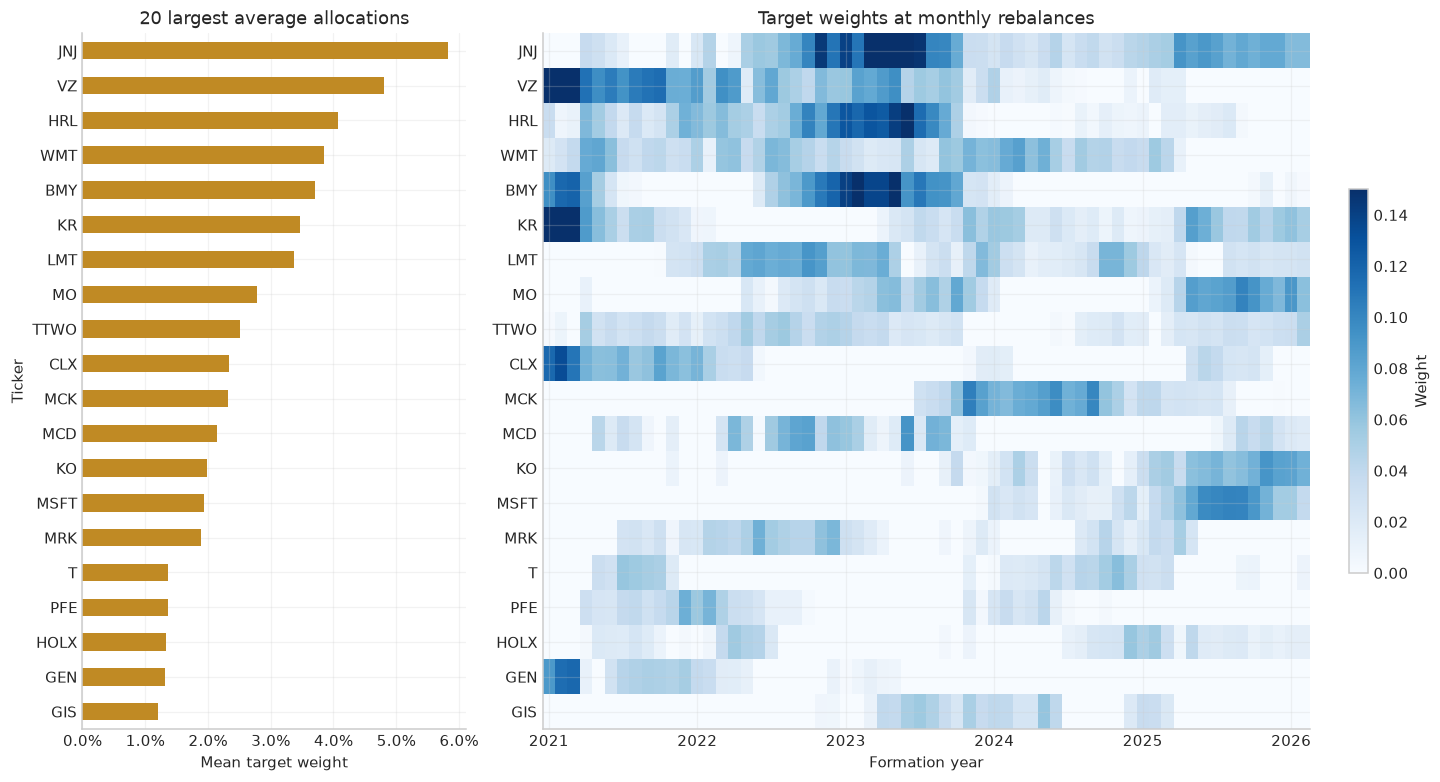

In [7]:
display(styled(test_table[["Annualized Turnover", "Total Transaction Costs", "Average HHI", "Average Effective Assets", "Mean Target L1 Change", "Solver Failures", "HMM Fallbacks"]]))
allocation_plot(test_results["pipeline1"], "pipeline1_test_weights")

### Performance conditional on a previously forecast regime

Dates are classified by the stress probability available at their most recent rebalance. This avoids labelling past observations with a model fitted using their future. Annualization within subsets is descriptive; regime rows are not separate investable portfolios.

In [8]:
conditional = regime_conditioned(test_results)
display(styled(conditional.set_index(["strategy", "regime"])))
uncertainty = paired_bootstrap(test_results["baseline"].returns.net_return, test_results["pipeline1"].returns.net_return)
display(uncertainty)

,difference,lower_95,upper_95
Annualized Volatility,-0.000087,-0.000603,0.000333
CVaR 95%,-0.000047,-0.000273,0.000145
Maximum Drawdown,0.001118,-0.009244,0.008444
Sharpe,0.008759,-0.037866,0.050635


## Takeaways

In [9]:
b, p = test_table.loc["baseline"], test_table.loc["pipeline1"]
display(Markdown(f"""Relative to the baseline, Pipeline 1 changes annual volatility by **{(p['Annualized Volatility']-b['Annualized Volatility'])*100:+.2f} percentage points**, daily CVaR95 by **{(p['CVaR 95%']-b['CVaR 95%'])*100:+.3f} points**, and maximum drawdown by **{(p['Maximum Drawdown']-b['Maximum Drawdown'])*100:+.2f} points**. Annual turnover changes from {b['Annualized Turnover']:.2f} to {p['Annualized Turnover']:.2f}. Regime conditioning must be judged through these incremental results and their uncertainty, not through model complexity alone."""))
print("HMM estimation failures are fail-fast; no silent baseline fallback was used.")

Relative to the baseline, Pipeline 1 changes annual volatility by **-0.01 percentage points**, daily CVaR95 by **-0.005 points**, and maximum drawdown by **+0.11 points**. Annual turnover changes from 5.61 to 5.95. Regime conditioning must be judged through these incremental results and their uncertainty, not through model complexity alone.

## Sources and methodological references

- Original local source notebooks: `price_EDA.ipynb`, `company_analisys.ipynb`; draft manuscript: `Portfolio optimization.docx`.
- [Kaggle price snapshot, version 1](https://www.kaggle.com/datasets/jacksaleeby/s-and-p500-historical-data): every ticker with complete coverage of all 6,573 source dates is retained. The provider's `Adj Close` is used as supplied; dividend/corporate-action adjustment quality is not independently certified.
- [SEC EDGAR XBRL API documentation](https://www.sec.gov/search-filings/edgar-application-programming-interfaces), [SEC identity reference](https://www.sec.gov/files/company_tickers_exchange.json). Identity reference data are used only to link issuers, not as historical predictive features.
- [CatBoost training parameters](https://catboost.ai/docs/en/references/training-parameters/common), [regression objectives](https://catboost.ai/docs/en/concepts/loss-functions-regression).
- Markowitz (1952), Ledoit & Wolf (2004), Hamilton (1989), Asness et al. (2019), Prokhorenkova et al. (2018): conceptual sources cited in the manuscript. The bespoke feature score and optimization penalties here are experimental implementations, not replicas of those papers.